<a href="https://colab.research.google.com/github/leonardeugenia-hash/TGF2026/blob/main/analisis_del_dato/analisis6_tendencia_ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Script 6 — Tendencia Temporal y Regresión Ridge (nivel anual)
**Input:** `dataset_completo_final_year.csv` (output del Script 2)  
**Output:** `tendencias_temporales.csv`, `coeficientes_ridge.csv`, `metricas_script6.csv`



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

COLORES_BASE = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange',
                'mediumpurple', 'goldenrod', 'slategray']

df = pd.read_csv('dataset_completo_final_year.csv')
df = df.sort_values('year').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Años: {df["year"].min()} – {df["year"].max()}')
print(f'N observaciones: {len(df)}')
print(f'Nulos: {df.isnull().sum().sum()}')
df.head()

Shape: (15, 78)
Años: 2010 – 2024
N observaciones: 15
Nulos: 0


,year,avg_duration,avg_popularity,std_popularity,avg_artist_popularity,explicit_ratio,n_songs,n_unique_artists,avg_years_since_rel,dominant_genre,pct_afrobeats,pct_amapiano,pct_argentine trap,pct_bachata,pct_bolero,pct_brazilian funk,pct_brazilian pop,pct_celtic rock,pct_chilean trap,pct_colombian pop,pct_corridos tumbados,pct_cuarteto,pct_dancehall,pct_dembow,pct_drill,pct_edm,pct_electro house,pct_europop,pct_flamenco,pct_flamenco pop,pct_flamenco urbano,pct_french r&b,pct_french rap,pct_house,pct_hyperpop,pct_indie,pct_k-pop,pct_kizomba,pct_latin,pct_latin afrobeats,pct_latin folk,pct_latin hip hop,pct_latin indie,pct_latin pop,pct_latin r&b,pct_latin rock,pct_laïko,pct_mariachi,pct_melbourne bounce,pct_merengue,pct_moombahton,pct_neoperreo,pct_pop,pct_rap,pct_reggaeton,pct_reggaeton chileno,pct_reggaeton mexa,pct_rkt,pct_rock en español,pct_singer-songwriter,pct_ska,pct_soft pop,pct_spanish-language reggae,pct_synthpop,pct_techengue,pct_trap latino,pct_tropical house,pct_trova,pct_unknown,pct_urbano latino,pct_villancicos,pib_per_capita,internet_access,pct_escucha_diaria,pct_suscripcion_total,pct_suscripcion_pago,trend_spotify_premium,trend_streaming_music
0,2010,226.99924,41.52,16.423279,54.24,0.00,50,42,0.56,unknown,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.02,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.08,0.0,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.10,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.04,0.04,0.00,0.0,0.02,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.02,30658.742228,65.8000,64.8,0.00,0.00,8.3,56.2
1,2011,229.11840,37.20,17.487021,51.42,0.02,50,41,-0.14,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.26,0.04,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.08,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.04,0.00,0.00,0.0,0.00,0.02,0.0,0.0,0.0,0.02,0.48,0.0,0.00,31824.621913,67.0900,64.8,0.67,0.33,17.2,30.6
2,2012,230.68654,43.46,17.881937,57.26,0.00,50,38,-0.16,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.04,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.24,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.0,0.0,0.02,0.00,0.00,0.00,0.0,0.02,0.00,0.0,0.0,0.0,0.02,0.36,0.0,0.00,28456.443815,69.8100,65.0,1.33,0.67,19.2,37.9
3,2013,224.66192,40.28,14.255740,54.00,0.00,50,40,-0.10,unknown,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.06,0.0,0.0,0.0,0.0,0.0,0.10,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.02,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.02,0.08,0.02,0.0,0.00,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.04,29228.846560,71.6350,65.2,2.00,1.00,17.7,45.9
4,2014,233.36278,43.24,16.213575,57.22,0.00,50,42,-0.02,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.20,0.04,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.14,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.00,0.02,0.04,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.00,29707.765509,76.1867,65.4,5.88,2.94,18.2,35.2


---
## 1. Variables de análisis

In [ ]:
# variables musicales a analizar
series_musicales = [
    ('avg_duration',          'Duración media (seg)'),
    ('avg_popularity',        'Popularidad media'),
    ('avg_artist_popularity', 'Popularidad artista media'),
    ('explicit_ratio',        'Ratio canciones explícitas'),
]
series_musicales = [(col, label) for col, label in series_musicales if col in df.columns]

# variables contextuales (predictores para Ridge)
features_contexto = [
    'pib_per_capita', 'internet_access',
    'pct_escucha_diaria', 'pct_suscripcion_total', 'pct_suscripcion_pago',
    'asistentes_conciertos_miles',
    'trend_spotify_premium', 'trend_streaming_music'
]
features_contexto = [f for f in features_contexto if f in df.columns]

print(f'Variables musicales disponibles ({len(series_musicales)}):')
for col, label in series_musicales:
    print(f'  {col}: {df[col].notna().sum()} observaciones no nulas')

print(f'\nVariables contextuales disponibles ({len(features_contexto)}):')
for f in features_contexto:
    print(f'  {f}: {df[f].notna().sum()} observaciones no nulas')

Variables musicales disponibles (4):
  avg_duration: 15 observaciones no nulas
  avg_popularity: 15 observaciones no nulas
  avg_artist_popularity: 15 observaciones no nulas
  explicit_ratio: 15 observaciones no nulas

Variables contextuales disponibles (7):
  pib_per_capita: 15 observaciones no nulas
  internet_access: 15 observaciones no nulas
  pct_escucha_diaria: 15 observaciones no nulas
  pct_suscripcion_total: 15 observaciones no nulas
  pct_suscripcion_pago: 15 observaciones no nulas
  trend_spotify_premium: 15 observaciones no nulas
  trend_streaming_music: 15 observaciones no nulas


---
## 2. MODELO A — Regresión de Tendencia Temporal

In [ ]:
tendencia_resultados = {}
tendencia_rows = []

for col, label in series_musicales:
    datos = df[['year', col]].dropna()
    x = datos['year'].values.astype(float)
    y = datos[col].values.astype(float)
    n_obs = len(datos)

    # regresión OLS simple
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r2 = r_value**2

    # predicciones e intervalos de confianza
    y_pred = intercept + slope * x
    residuos = y - y_pred

    # variación total acumulada 2010-2024
    cambio_total = slope * (datos['year'].max() - datos['year'].min())
    cambio_pct   = (cambio_total / abs(y.mean())) * 100 if y.mean() != 0 else np.nan

    sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.'))
    direccion = '↑ Creciente' if slope > 0 else '↓ Decreciente'

    tendencia_resultados[col] = {
        'slope': slope, 'intercept': intercept, 'r2': r2,
        'p_value': p_value, 'std_err': std_err,
        'cambio_total': cambio_total, 'cambio_pct': cambio_pct,
        'x': x, 'y': y, 'y_pred': y_pred, 'label': label, 'n': n_obs
    }
    tendencia_rows.append({
        'Variable': col, 'Etiqueta': label,
        'Pendiente (β₁)': round(slope, 4),
        'R²': round(r2, 4),
        'p-valor': round(p_value, 4),
        'Significatividad': sig,
        'Dirección': direccion,
        'Cambio total 2010-2024': f'{cambio_total:+.2f}',
        'Cambio relativo (%)': f'{cambio_pct:+.1f}%' if not np.isnan(cambio_pct) else 'N/A',
        'N observaciones': n_obs
    })

df_tendencias = pd.DataFrame(tendencia_rows)
print('Resultados — Regresión de Tendencia Temporal (2010-2024):')
print(df_tendencias[['Variable', 'Pendiente (β₁)', 'R²', 'p-valor', 'Significatividad',
                      'Dirección', 'Cambio total 2010-2024']].to_string(index=False))
print('\nSignificatividad: *** p<0.001 | ** p<0.01 | * p<0.05 | n.s. no significativa')

Resultados — Regresión de Tendencia Temporal (2010-2024):
             Variable  Pendiente (β₁)     R²  p-valor Significatividad     Dirección Cambio total 2010-2024
         avg_duration         -2.7103 0.8736      0.0              *** ↓ Decreciente                 -37.94
       avg_popularity          2.0944 0.8046      0.0              ***   ↑ Creciente                 +29.32
avg_artist_popularity          1.7735 0.8629      0.0              ***   ↑ Creciente                 +24.83
       explicit_ratio          0.0286 0.8115      0.0              ***   ↑ Creciente                  +0.40

Significatividad: *** p<0.001 | ** p<0.01 | * p<0.05 | n.s. no significativa


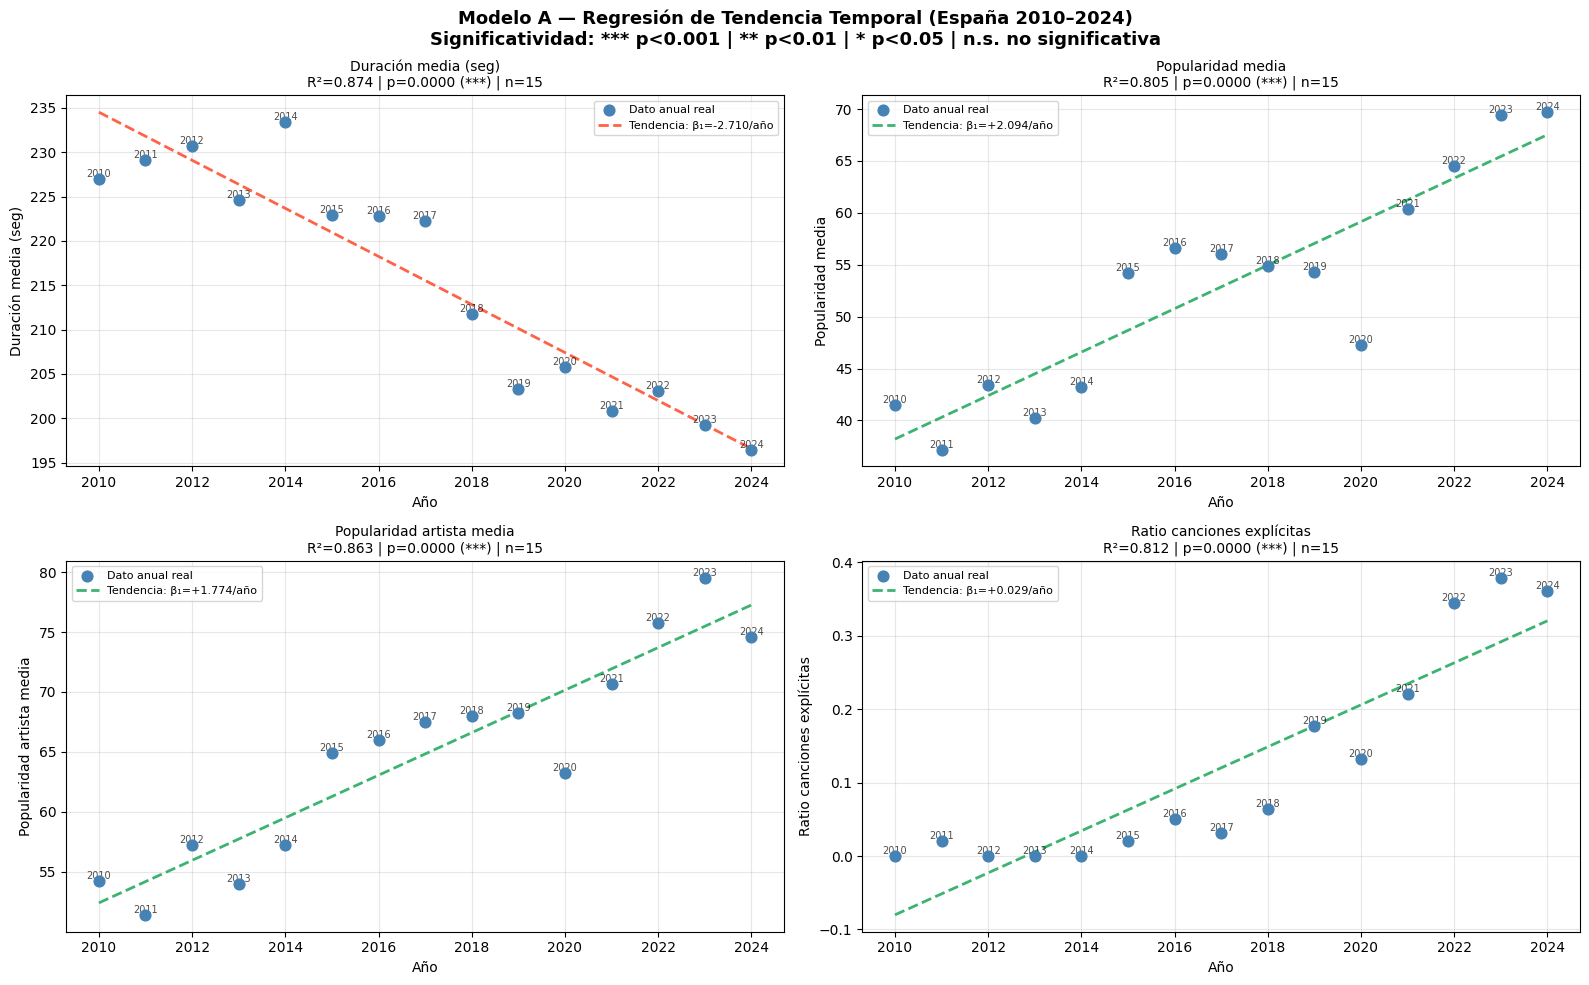

In [ ]:
n_series = len(series_musicales)
n_cols_plot = 2
n_rows_plot = (n_series + 1) // 2

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 5 * n_rows_plot))
axes = axes.flatten() if n_series > 1 else [axes]

for i, (col, label) in enumerate(series_musicales):
    ax = axes[i]
    r = tendencia_resultados[col]

    # datos reales
    ax.scatter(r['x'], r['y'], color='steelblue', s=60, zorder=4,
               label='Dato anual real')

    # anotaciones de año
    for xi, yi in zip(r['x'], r['y']):
        ax.annotate(str(int(xi)), (xi, yi), fontsize=7,
                    ha='center', va='bottom', alpha=0.7)

    # linea de tendencia
    x_line = np.array([r['x'].min(), r['x'].max()])
    y_line = r['intercept'] + r['slope'] * x_line
    color_trend = 'tomato' if r['slope'] < 0 else 'mediumseagreen'
    ax.plot(x_line, y_line, '--', color=color_trend, lw=2,
            label=f'Tendencia: β₁={r["slope"]:+.3f}/año')

    sig = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else 'n.s.'))
    ax.set_title(f'{label}\nR²={r["r2"]:.3f} | p={r["p_value"]:.4f} ({sig}) | n={r["n"]}',
                 fontsize=10)
    ax.set_xlabel('Año')
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Modelo A — Regresión de Tendencia Temporal (España 2010–2024)\n'             'Significatividad: *** p<0.001 | ** p<0.01 | * p<0.05 | n.s. no significativa',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# tabla resumen
df_tendencias.set_index('Variable').style \
    .background_gradient(cmap='Blues', subset=['R²']) \
    .background_gradient(cmap='Reds', subset=['p-valor']) \
    .applymap(lambda v: 'font-weight: bold; color: #155724' if '*' in str(v) else '',
              subset=['Significatividad']) \
    .set_caption('Modelo A — Resumen de tendencias temporales (2010–2024)') \
    .set_table_styles([
        {'selector': 'th.col_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px 12px')]},
        {'selector': 'th.row_heading',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '8px 12px')]},
        {'selector': 'th.blank, th.index_name',
         'props': [('background-color', '#1a3a5c'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px 12px')]},
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('padding-bottom', '8px'), ('text-align', 'center')]}
    ])

,Etiqueta,Pendiente (β₁),R²,p-valor,Significatividad,Dirección,Cambio total 2010-2024,Cambio relativo (%),N observaciones
Variable,,,,,,,,,
avg_duration,Duración media (seg),-2.710300,0.873600,0.000000,***,↓ Decreciente,-37.94,-17.6%,15
avg_popularity,Popularidad media,2.094400,0.804600,0.000000,***,↑ Creciente,+29.32,+55.5%,15
avg_artist_popularity,Popularidad artista media,1.773500,0.862900,0.000000,***,↑ Creciente,+24.83,+38.3%,15
explicit_ratio,Ratio canciones explícitas,0.028600,0.811500,0.000000,***,↑ Creciente,+0.40,+333.3%,15


---
## 3. MODELO B — Regresión Ridge con LOO-CV

In [ ]:
targets_ridge = [col for col, _ in series_musicales if col in df.columns]

# dataset completo para Ridge (eliminar nulos en predictores y targets)
df_ridge = df[['year'] + features_contexto + targets_ridge].dropna().reset_index(drop=True)
print(f'Observaciones para Ridge: {len(df_ridge)} (de {len(df)})')
print(f'Años: {df_ridge["year"].min()} – {df_ridge["year"].max()}')
print(f'Predictores contextuales: {len(features_contexto)}')

X_ridge_raw = df_ridge[features_contexto]
scaler_ridge = StandardScaler()
X_ridge = scaler_ridge.fit_transform(X_ridge_raw)

# selección de lambda óptimo por LOO-CV para cada target
alphas_grid = np.logspace(-3, 4, 100)  # λ de 0.001 a 10000

ridge_resultados = {}

print('\n' + '=' * 65)
print('RIDGE — Selección de λ óptimo por LOO-CV (PRESS)')
print('=' * 65)
print(f'  {"Variable objetivo":<30} {"λ óptimo":>10} {"R² LOO":>8} {"MAE LOO":>10}')
print('-' * 65)

for target in targets_ridge:
    y_target = df_ridge[target].values
    label = dict(series_musicales)[target]

    # ridgeCV con LOO para selección de lambda
    ridge_cv = RidgeCV(alphas=alphas_grid, cv=LeaveOneOut())
    ridge_cv.fit(X_ridge, y_target)
    alpha_opt = ridge_cv.alpha_

    # ajuste final con lambda óptimo y métricas LOO
    loo = LeaveOneOut()
    y_true_loo, y_pred_loo = [], []

    for train_idx, test_idx in loo.split(X_ridge):
        ridge_fold = Ridge(alpha=alpha_opt)
        ridge_fold.fit(X_ridge[train_idx], y_target[train_idx])
        y_pred_loo.append(ridge_fold.predict(X_ridge[test_idx])[0])
        y_true_loo.append(y_target[test_idx[0]])

    mae_loo  = mean_absolute_error(y_true_loo, y_pred_loo)
    rmse_loo = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))
    r2_loo   = r2_score(y_true_loo, y_pred_loo)

    # ajuste final sobre todos los datos para coeficientes
    ridge_final = Ridge(alpha=alpha_opt)
    ridge_final.fit(X_ridge, y_target)

    coeficientes = pd.Series(ridge_final.coef_, index=features_contexto)

    ridge_resultados[target] = {
        'alpha': alpha_opt, 'model': ridge_final,
        'coeficientes': coeficientes,
        'mae_loo': mae_loo, 'rmse_loo': rmse_loo, 'r2_loo': r2_loo,
        'y_true_loo': y_true_loo, 'y_pred_loo': y_pred_loo,
        'label': label
    }
    print(f'  {target:<30} {alpha_opt:>10.3f} {r2_loo:>8.4f} {mae_loo:>10.4f}')

Observaciones para Ridge: 15 (de 15)
Años: 2010 – 2024
Predictores contextuales: 7

RIDGE — Selección de λ óptimo por LOO-CV (PRESS)
  Variable objetivo                λ óptimo   R² LOO    MAE LOO
-----------------------------------------------------------------
  avg_duration                        0.001   0.8042     3.8777
  avg_popularity                      0.001   0.5108     5.6469
  avg_artist_popularity               0.001   0.5134     4.8739
  explicit_ratio                      0.001   0.6667     0.0641


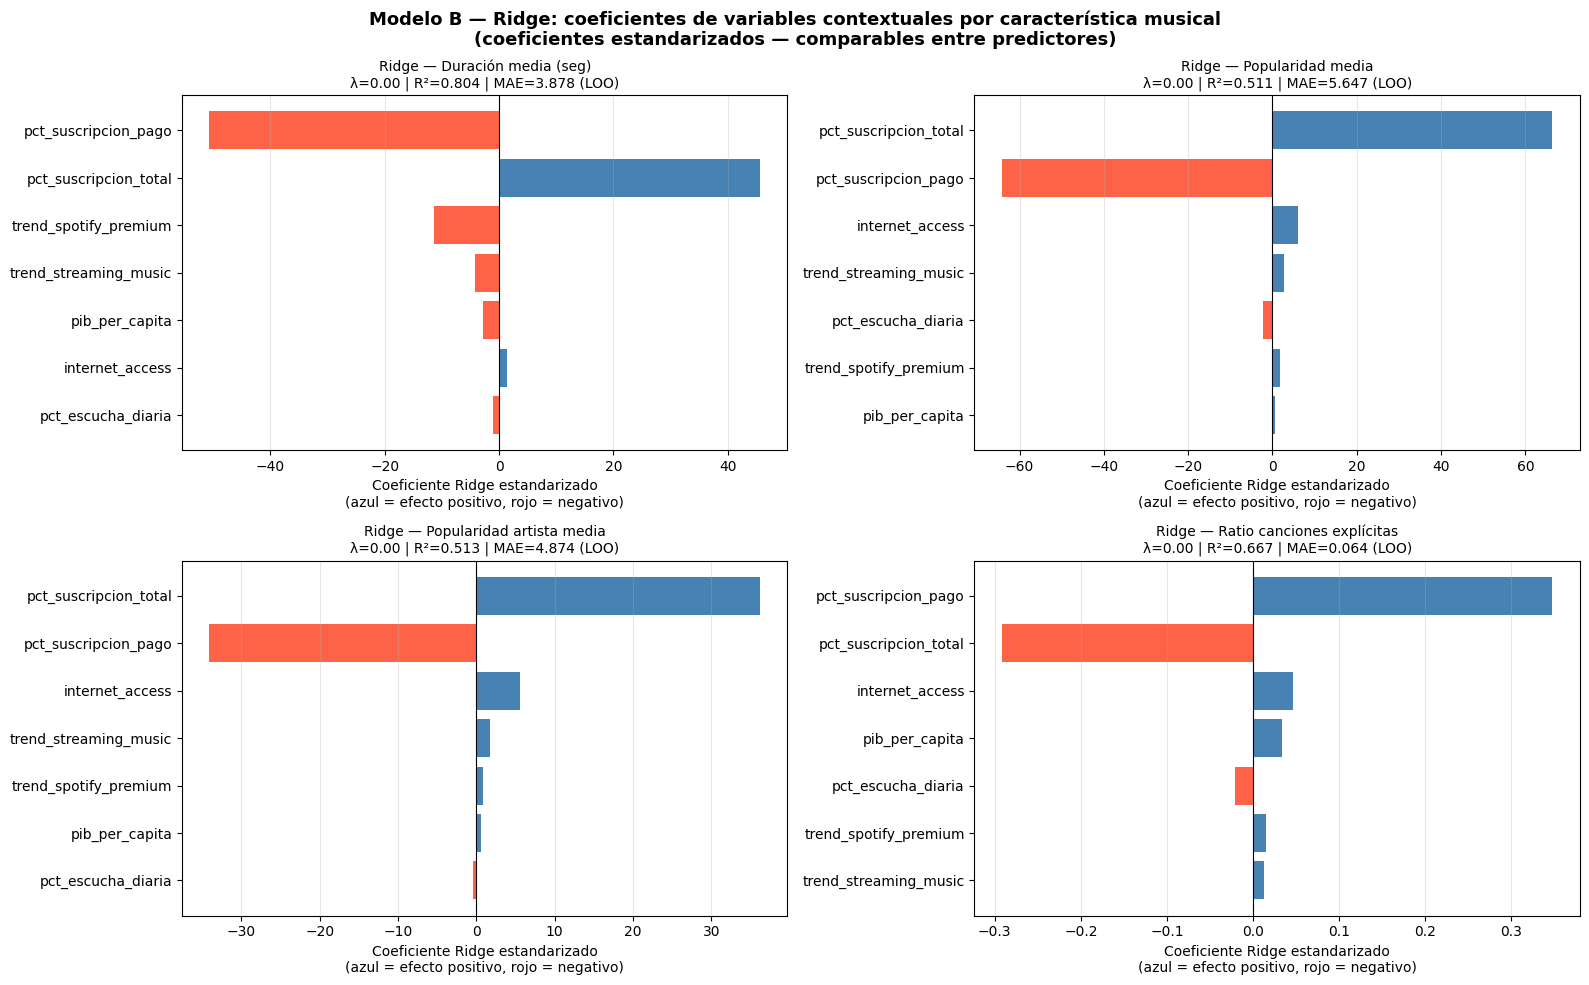

In [ ]:
# visualización de coeficientes por variable objetivo
n_targets = len(targets_ridge)
n_cols_p = min(2, n_targets)
n_rows_p = (n_targets + 1) // 2

fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 5 * n_rows_p))
axes = axes.flatten() if n_targets > 1 else [axes]

for i, target in enumerate(targets_ridge):
    ax = axes[i]
    r = ridge_resultados[target]
    coef = r['coeficientes'].sort_values(key=abs, ascending=True)

    colores_coef = ['steelblue' if v > 0 else 'tomato' for v in coef.values]
    ax.barh(coef.index, coef.values, color=colores_coef)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Ridge — {r["label"]}\n'
                 f'λ={r["alpha"]:.2f} | R²={r["r2_loo"]:.3f} | MAE={r["mae_loo"]:.3f} (LOO)',
                 fontsize=10)
    ax.set_xlabel('Coeficiente Ridge estandarizado\n(azul = efecto positivo, rojo = negativo)')
    ax.grid(axis='x', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Modelo B — Ridge: coeficientes de variables contextuales por característica musical\n'
             '(coeficientes estandarizados — comparables entre predictores)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

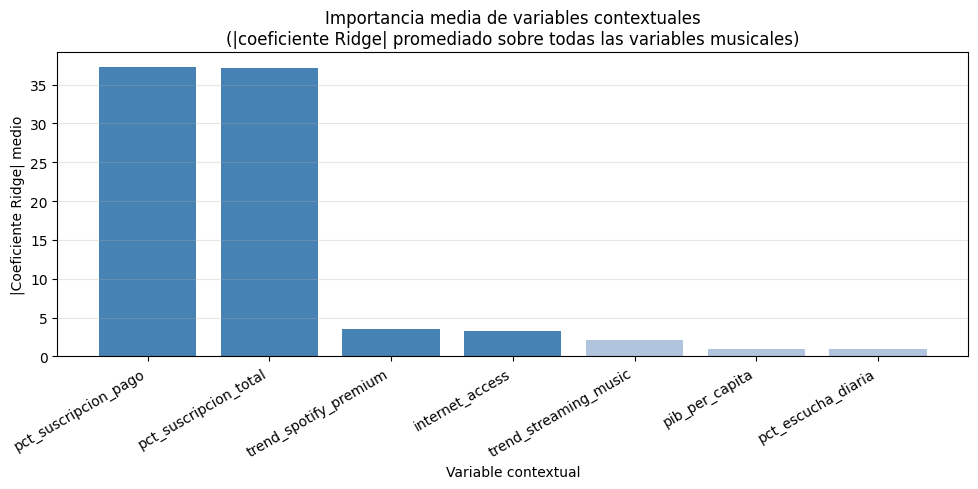

Ranking de variables contextuales por importancia media (Ridge):
  1. pct_suscripcion_pago: 37.3088
  2. pct_suscripcion_total: 37.1457
  3. trend_spotify_premium: 3.5292
  4. internet_access: 3.2521
  5. trend_streaming_music: 2.1464
  6. pib_per_capita: 0.9854
  7. pct_escucha_diaria: 0.9431


In [ ]:
# ranking de importancia media (valor absoluto del coeficiente promedio)
coef_matrix = pd.DataFrame({t: ridge_resultados[t]['coeficientes'] for t in targets_ridge})
importancia_media = coef_matrix.abs().mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colores_imp = ['steelblue' if v >= importancia_media.median() else 'lightsteelblue'
               for v in importancia_media.values]
ax.bar(importancia_media.index, importancia_media.values, color=colores_imp)
ax.set_title('Importancia media de variables contextuales\n'             '(|coeficiente Ridge| promediado sobre todas las variables musicales)',
             fontsize=12)
ax.set_xlabel('Variable contextual')
ax.set_ylabel('|Coeficiente Ridge| medio')
ax.set_xticklabels(importancia_media.index, rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Ranking de variables contextuales por importancia media (Ridge):')
for rank, (var, imp) in enumerate(importancia_media.items(), 1):
    print(f'  {rank}. {var}: {imp:.4f}')

---
## 6. COMPARACIÓN Y MÉTRICAS FINALES

In [ ]:
print('=' * 70)
print('RESUMEN DE MÉTRICAS — SCRIPT 6')
print('=' * 70)

print('\nMODELO A — Regresión de Tendencia Temporal:')
print(f'  {"Variable":<30} {"Pendiente":>10} {"R²":>8} {"p-valor":>10} {"Sig.":>6}')
print('  ' + '-' * 68)
for col, label in series_musicales:
    r = tendencia_resultados[col]
    sig = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else 'n.s.'))
    print(f'  {col:<30} {r["slope"]:>+10.4f} {r["r2"]:>8.4f} {r["p_value"]:>10.4f} {sig:>6}')

print('\nMODELO B — Ridge con LOO-CV:')
print(f'  {"Variable objetivo":<30} {"λ óptimo":>10} {"R² LOO":>8} {"MAE LOO":>10}')
print('  ' + '-' * 62)
for target in targets_ridge:
    r = ridge_resultados[target]
    print(f'  {target:<30} {r["alpha"]:>10.3f} {r["r2_loo"]:>8.4f} {r["mae_loo"]:>10.4f}')

print(f'\nVariable contextual más influyente: {importancia_media.index[0]} ({importancia_media.values[0]:.4f})')
if len(importancia_media) > 1:
    print(f'Segunda más influyente:             {importancia_media.index[1]} ({importancia_media.values[1]:.4f})')



RESUMEN DE MÉTRICAS — SCRIPT 6

MODELO A — Regresión de Tendencia Temporal:
  Variable                        Pendiente       R²    p-valor   Sig.
  --------------------------------------------------------------------
  avg_duration                      -2.7103   0.8736     0.0000    ***
  avg_popularity                    +2.0944   0.8046     0.0000    ***
  avg_artist_popularity             +1.7735   0.8629     0.0000    ***
  explicit_ratio                    +0.0286   0.8115     0.0000    ***

MODELO B — Ridge con LOO-CV:
  Variable objetivo                λ óptimo   R² LOO    MAE LOO
  --------------------------------------------------------------
  avg_duration                        0.001   0.8042     3.8777
  avg_popularity                      0.001   0.5108     5.6469
  avg_artist_popularity               0.001   0.5134     4.8739
  explicit_ratio                      0.001   0.6667     0.0641

Variable contextual más influyente: pct_suscripcion_pago (37.3088)
Segunda más inf

---
## 7. GUARDADO

In [ ]:
# Tendencias temporales
df_tendencias.to_csv('tendencias_temporales.csv', index=False)
print('✅ tendencias_temporales.csv guardado')

# Coeficientes Ridge
coef_matrix_export = coef_matrix.copy()
coef_matrix_export['importancia_media'] = importancia_media
coef_matrix_export.to_csv('coeficientes_ridge.csv')
print('✅ coeficientes_ridge.csv guardado')

# Métricas consolidadas Script 6
metricas_s6_rows = []
for col, label in series_musicales:
    r_t = tendencia_resultados[col]
    sig = '***' if r_t['p_value'] < 0.001 else ('**' if r_t['p_value'] < 0.01 else ('*' if r_t['p_value'] < 0.05 else 'n.s.'))
    row = {
        'Variable': col, 'Etiqueta': label,
        'Modelo_A_pendiente': round(r_t['slope'], 4),
        'Modelo_A_R2': round(r_t['r2'], 4),
        'Modelo_A_pvalor': round(r_t['p_value'], 4),
        'Modelo_A_sig': sig,
    }
    if col in ridge_resultados:
        r_r = ridge_resultados[col]
        row.update({
            'Modelo_B_lambda': round(r_r['alpha'], 3),
            'Modelo_B_R2_LOO': round(r_r['r2_loo'], 4),
            'Modelo_B_MAE_LOO': round(r_r['mae_loo'], 4),
        })
    metricas_s6_rows.append(row)

pd.DataFrame(metricas_s6_rows).to_csv('metricas_script6.csv', index=False)
print('✅ metricas_script6.csv guardado')

✅ tendencias_temporales.csv guardado
✅ coeficientes_ridge.csv guardado
✅ metricas_script6.csv guardado
